## Cell 1 — Imports & Setup

In [13]:
import sys, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path().absolute().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.database     import get_vector_store
from src.retrievers import get_retriever
from src.rag_chain  import get_qa_chain
from src.config     import LLM_MODEL, EMBEDDING_MODEL, CHUNK_SIZE, RESULTS_DIR

from gold_standard  import GOLD_STANDARD

PALETTE   = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
STRATEGIES = ['Sparse (BM25)', 'Dense (Vector)', 'Hybrid + Rerank', 'HyDE']

print(f'Setup OK — {len(GOLD_STANDARD)} gold queries loaded')

Setup OK — 30 gold queries loaded


## Cell 2 — Load Vector Store

In [14]:
vector_store = get_vector_store()
print(f'ChromaDB: {vector_store._collection.count()} chunks')

Loading existing ChromaDB …
 Loaded 5820 chunks.
ChromaDB: 5820 chunks


## Cell 3 — Preview Gold Standard

In [15]:
df_gs = pd.DataFrame(GOLD_STANDARD)
print(df_gs[['category','difficulty']].value_counts().to_string())
print()
df_gs[['id','category','difficulty','query']]

category              difficulty
direct_module         easy          6
comparative           hard          5
curriculum_structure  medium        4
recommendation        medium        4
logistics             easy          3
curriculum_structure  hard          2
recommendation        hard          2
comparative           medium        1
direct_module         medium        1
logistics             medium        1
recommendation        easy          1



,id,category,difficulty,query
0,Q01,direct_module,easy,What is the module Advanced Machine Learning a...
1,Q02,direct_module,easy,How many credit points is the Advanced Machine...
2,Q03,direct_module,easy,What are the recommended prerequisites for Adv...
3,Q04,direct_module,easy,Who is responsible for the Advanced Machine Le...
4,Q05,direct_module,easy,What type of examination does the Advanced Mac...
5,Q06,direct_module,medium,What topics are taught in the Advanced Machine...
6,Q07,direct_module,easy,In which semester is the Advanced Machine Lear...
7,Q08,curriculum_structure,medium,Is Advanced Machine Learning compulsory for Da...
8,Q09,curriculum_structure,medium,Which TUHH programs include Advanced Machine L...
9,Q10,curriculum_structure,medium,What is the workload for the Advanced Machine ...


## Cell 4 — Evaluation Metrics

| Metric | Definition |
|---|---|
| **Hit@5** | 1 if ≥1 of the top-5 chunks contains an expected keyword |
| **KW Coverage** | Fraction of expected keywords found in top-5 chunks |
| **MRR** | 1 / rank of first relevant chunk (higher = better) |
| **Latency** | Wall-clock seconds per query (includes LLM answer generation) |

In [16]:
def hit_at_k(docs, kw, k=5):
    """Binary: did any top-k chunk contain at least one expected keyword?"""
    body = ' '.join(d.page_content.lower() for d in docs[:k])
    return int(any(w.lower() in body for w in kw))

def kw_coverage(docs, kw, k=5):
    """Fraction of expected keywords found in top-k chunks."""
    if not kw:
        return 0.0
    body = ' '.join(d.page_content.lower() for d in docs[:k])
    return sum(1 for w in kw if w.lower() in body) / len(kw)

def mrr(docs, kw, k=5):
    """Mean Reciprocal Rank — 1/rank of first relevant chunk."""
    for rank, doc in enumerate(docs[:k], 1):
        if any(w.lower() in doc.page_content.lower() for w in kw):
            return 1.0 / rank
    return 0.0

print('Metrics defined')

Metrics defined


In [17]:
rows = []

for strat in STRATEGIES:
    print(f'\n{"═"*55}')
    print(f'  Strategy: {strat}')
    print(f'{"═"*55}')

    retriever = get_retriever(strat, vector_store)
    chain     = get_qa_chain(retriever)

    for item in GOLD_STANDARD:
        t0 = time.time()
        try:
            resp   = chain.invoke({'input': item['query']})
            docs   = resp['context']
            answer = resp['answer']
        except Exception as e:
            docs, answer = [], f'ERROR: {e}'
            print(f'  ❌  {item["id"]}: {e}')

        lat = round(time.time() - t0, 2)
        kw  = item['expected_keywords']

        rows.append(dict(
            strategy   = strat,
            query_id   = item['id'],
            category   = item['category'],
            difficulty = item['difficulty'],
            query      = item['query'],
            gold_answer= item['gold_answer'],
            hit_at_5   = hit_at_k(docs, kw),
            kw_cov     = round(kw_coverage(docs, kw), 3),
            mrr        = round(mrr(docs, kw), 3),
            latency_s  = lat,
            answer     = answer,
            n_docs     = len(docs),
        ))

        icon = '✅' if rows[-1]['hit_at_5'] else '❌'
        print(f"  {icon}  {item['id']} [{item['difficulty']:6}]  "
              f"Hit={rows[-1]['hit_at_5']}  "
              f"Cov={rows[-1]['kw_cov']:.2f}  "
              f"MRR={rows[-1]['mrr']:.2f}  "
              f"{lat:.1f}s")

results_df = pd.DataFrame(rows)

safe_llm = LLM_MODEL.replace(":", "_")
safe_embed = EMBEDDING_MODEL.replace(":", "_")

exp_filename = f"exp_llm[{safe_llm}]_embed[{safe_embed}]_chunk[{CHUNK_SIZE}].csv"

output_path = RESULTS_DIR / exp_filename
results_df.to_csv(output_path, index=False)

print(f'\nEvaluation complete — {len(results_df)} rows saved.')
print(f'File saved as: {exp_filename}')


═══════════════════════════════════════════════════════
  Strategy: Sparse (BM25)
═══════════════════════════════════════════════════════
 Initialising: Sparse (BM25)
  ✅  Q01 [easy  ]  Hit=1  Cov=0.75  MRR=1.00  17.3s
  ✅  Q02 [easy  ]  Hit=1  Cov=1.00  MRR=1.00  3.0s
  ✅  Q03 [easy  ]  Hit=1  Cov=0.67  MRR=0.25  6.4s
  ✅  Q04 [easy  ]  Hit=1  Cov=1.00  MRR=1.00  4.5s
  ❌  Q05 [easy  ]  Hit=0  Cov=0.00  MRR=0.00  3.6s
  ❌  Q06 [medium]  Hit=0  Cov=0.00  MRR=0.00  4.2s
  ❌  Q07 [easy  ]  Hit=0  Cov=0.00  MRR=0.00  5.8s
  ✅  Q08 [medium]  Hit=1  Cov=1.00  MRR=1.00  13.3s
  ✅  Q09 [medium]  Hit=1  Cov=0.33  MRR=0.25  12.9s
  ✅  Q10 [medium]  Hit=1  Cov=0.75  MRR=0.20  5.8s
  ✅  Q11 [medium]  Hit=1  Cov=1.00  MRR=1.00  3.1s
  ✅  Q12 [hard  ]  Hit=1  Cov=1.00  MRR=1.00  12.8s
  ✅  Q13 [hard  ]  Hit=1  Cov=1.00  MRR=1.00  10.4s
  ✅  Q14 [medium]  Hit=1  Cov=0.33  MRR=1.00  13.7s
  ✅  Q15 [easy  ]  Hit=1  Cov=0.33  MRR=1.00  10.2s
  ✅  Q16 [medium]  Hit=1  Cov=0.67  MRR=1.00  21.0s
  ✅  Q17

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Reranker ready.
  ✅  Q01 [easy  ]  Hit=1  Cov=0.25  MRR=0.20  14.5s
  ✅  Q02 [easy  ]  Hit=1  Cov=0.67  MRR=1.00  16.1s
  ✅  Q03 [easy  ]  Hit=1  Cov=0.33  MRR=1.00  14.5s
  ❌  Q04 [easy  ]  Hit=0  Cov=0.00  MRR=0.00  12.4s
  ✅  Q05 [easy  ]  Hit=1  Cov=1.00  MRR=1.00  9.0s
  ❌  Q06 [medium]  Hit=0  Cov=0.00  MRR=0.00  7.4s
  ❌  Q07 [easy  ]  Hit=0  Cov=0.00  MRR=0.00  11.1s
  ❌  Q08 [medium]  Hit=0  Cov=0.00  MRR=0.00  10.0s
  ✅  Q09 [medium]  Hit=1  Cov=0.67  MRR=1.00  14.3s
  ✅  Q10 [medium]  Hit=1  Cov=1.00  MRR=1.00  12.7s
  ✅  Q11 [medium]  Hit=1  Cov=1.00  MRR=1.00  11.4s
  ✅  Q12 [hard  ]  Hit=1  Cov=1.00  MRR=1.00  17.6s
  ✅  Q13 [hard  ]  Hit=1  Cov=1.00  MRR=1.00  9.3s
  ✅  Q14 [medium]  Hit=1  Cov=0.67  MRR=1.00  21.5s
  ✅  Q15 [easy  ]  Hit=1  Cov=0.33  MRR=1.00  19.5s
  ❌  Q16 [medium]  Hit=0  Cov=0.00  MRR=0.00  11.8s
  ✅  Q17 [hard  ]  Hit=1  Cov=0.67  MRR=1.00  26.0s
  ✅  Q18 [medium]  Hit=1  Cov=0.67  MRR=1.00  24.4s
  ✅  Q19 [hard  ]  Hit=1  Cov=0.50  MRR=0.50  23.6

## Cell 6 — Summary Table

In [18]:
summary = (
    results_df
    .groupby('strategy', sort=False)
    .agg(
        Hit_Rate   =('hit_at_5',  'mean'),
        MRR        =('mrr',       'mean'),
        KW_Coverage=('kw_cov',    'mean'),
        Latency_s  =('latency_s', 'mean'),
        N          =('query_id',  'count'),
    )
    .round(3)
    .sort_values('Hit_Rate', ascending=False)
    .reset_index()
)

summary.to_csv(RESULTS_DIR / 'summary.csv', index=False)

print('TABLE 1 — RAG Strategy Performance (30 queries, Top-5 retrieval)')
print('='*60)
print(summary[['strategy','Hit_Rate','MRR','KW_Coverage','Latency_s']].to_string(index=False))
print('='*60)
print('Hit_Rate = fraction of queries with ≥1 keyword hit in top-5 chunks')
print('MRR      = mean reciprocal rank of first relevant chunk')
print('KW_Cov   = avg fraction of expected keywords found')
print('Latency  = avg seconds per query (includes LLM answer generation)')

TABLE 1 — RAG Strategy Performance (30 queries, Top-5 retrieval)
       strategy  Hit_Rate   MRR  KW_Coverage  Latency_s
  Sparse (BM25)     0.833 0.655        0.547     10.291
 Dense (Vector)     0.800 0.598        0.536     14.293
Hybrid + Rerank     0.800 0.757        0.567     16.181
           HyDE     0.800 0.651        0.542     22.952
Hit_Rate = fraction of queries with ≥1 keyword hit in top-5 chunks
MRR      = mean reciprocal rank of first relevant chunk
KW_Cov   = avg fraction of expected keywords found
Latency  = avg seconds per query (includes LLM answer generation)


## Cell 7 — Bar Chart: Strategy Comparison

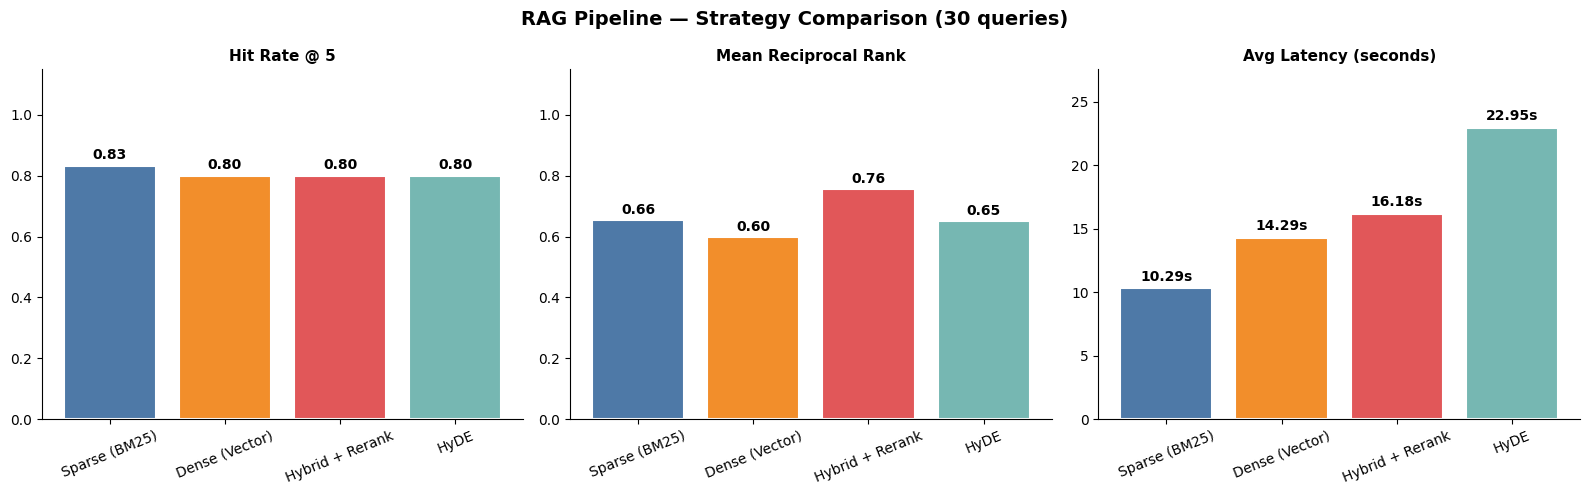

Saved: results/fig1_bars.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RAG Pipeline — Strategy Comparison (30 queries)',
             fontsize=14, fontweight='bold')

metrics = [
    ('Hit_Rate',  'Hit Rate @ 5',          (0, 1.15)),
    ('MRR',       'Mean Reciprocal Rank',   (0, 1.15)),
    ('Latency_s', 'Avg Latency (seconds)',  None),
]

for ax, (col, title, ylim) in zip(axes, metrics):
    vals = summary[col]
    bars = ax.bar(summary['strategy'], vals, color=PALETTE,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=11)
    if ylim:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(0, vals.max() * 1.2)
    ax.tick_params(axis='x', rotation=22)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, vals):
        suffix = 's' if col == 'Latency_s' else ''
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + vals.max() * 0.025,
                f'{v:.2f}{suffix}', ha='center',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig1_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/fig1_bars.png')

## Cell 8 — Heatmaps: Category & Difficulty Breakdown

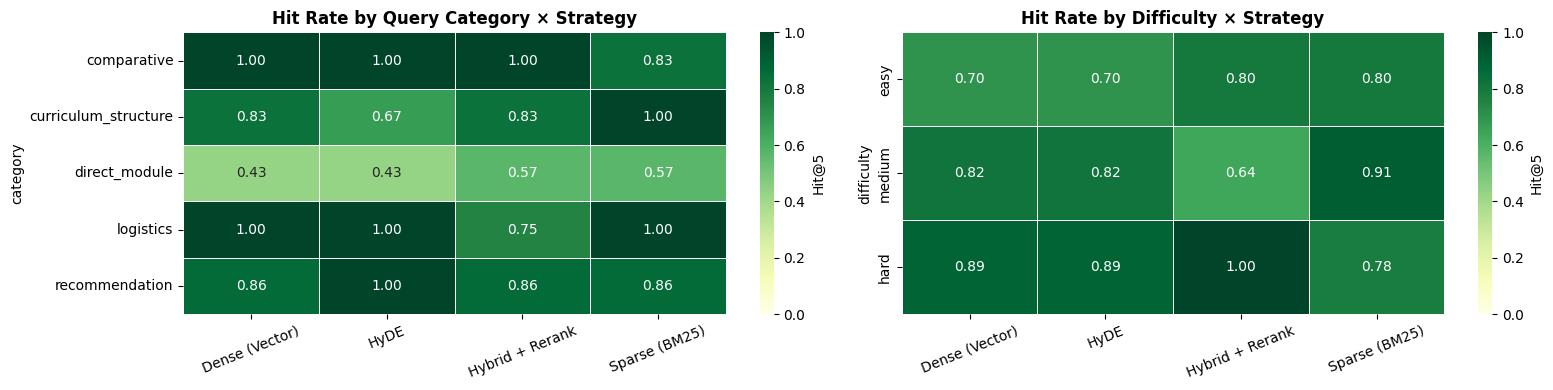

Saved: results/fig2_heatmaps.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, idx, title in [
    (axes[0], 'category',   'Hit Rate by Query Category × Strategy'),
    (axes[1], 'difficulty', 'Hit Rate by Difficulty × Strategy'),
]:
    pivot = results_df.pivot_table(
        index=idx, columns='strategy', values='hit_at_5', aggfunc='mean'
    ).round(2)
    if idx == 'difficulty':
        order = [r for r in ['easy', 'medium', 'hard'] if r in pivot.index]
        pivot = pivot.reindex(order)
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGn',
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Hit@5'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=22)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/fig2_heatmaps.png')

## Cell 9 — Radar Chart

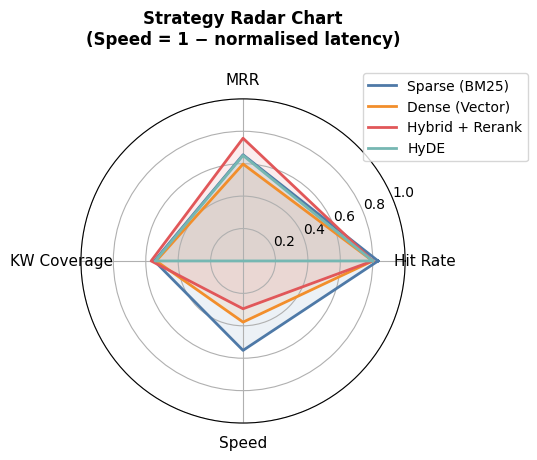

Saved: results/fig3_radar.png


In [21]:
summary['Speed'] = 1 - (summary['Latency_s'] / summary['Latency_s'].max())

cats   = ['Hit Rate', 'MRR', 'KW Coverage', 'Speed']
N      = len(cats)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for i, row in summary.iterrows():
    vals = [
        row['Hit_Rate'], row['MRR'], row['KW_Coverage'], row['Speed'],
        row['Hit_Rate'],
    ]
    ax.plot(angles, vals, lw=2, color=PALETTE[i], label=row['strategy'])
    ax.fill(angles, vals, alpha=0.10, color=PALETTE[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Strategy Radar Chart\n(Speed = 1 − normalised latency)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig3_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/fig3_radar.png')

## Cell 10 — Qualitative Analysis

In [22]:
SAMPLE_ID = 'Q14'   # Change to any Q01–Q30

sample = results_df[results_df['query_id'] == SAMPLE_ID]
print(f'Query : {sample["query"].iloc[0]}')
print(f'Gold  : {sample["gold_answer"].iloc[0]}')
print('─' * 70)

for _, row in sample.iterrows():
    icon = '✅' if row['hit_at_5'] else '❌'
    ans  = row['answer'].replace('\n', ' ').strip()[:350]
    print(f"\n{icon}  [{row['strategy']}]  MRR={row['mrr']}  Latency={row['latency_s']}s")
    print(f"   {ans}…")

Query : I love mathematics and programming. What should I study at TUHH?
Gold  : Data Science or Computer Science would suit you well — both require strong mathematical foundations and programming (Python).
──────────────────────────────────────────────────────────────────────

✅  [Sparse (BM25)]  MRR=1.0  Latency=13.73s
   Based on your interests in mathematics and programming, I would recommend studying the Master's program "Information and Communication Systems" (M.Sc.) at TUHH.  This program seems to be a good match for you because it combines mathematical foundations with technical aspects of computer science and communication technology. The Advanced Seminar EIM…

✅  [Dense (Vector)]  MRR=1.0  Latency=28.73s
   Based on your interests in mathematics and programming, I would recommend the Master's program in Computer Science (Masters Comp Sci). This program seems to align well with your strengths, as it covers topics such as principles of math (algebra, analysis/calculus), princip

In [23]:
# Failed queries per strategy
print('FAILED QUERIES (Hit@5 = 0)\n')
for s in STRATEGIES:
    fails = results_df[(results_df['strategy'] == s) & (results_df['hit_at_5'] == 0)]
    ids   = ', '.join(fails['query_id'].tolist()) or 'None'
    print(f'  {s:<22}  {len(fails):>2} failures  → {ids}')

FAILED QUERIES (Hit@5 = 0)

  Sparse (BM25)            5 failures  → Q05, Q06, Q07, Q19, Q27
  Dense (Vector)           6 failures  → Q03, Q04, Q06, Q07, Q08, Q19
  Hybrid + Rerank          6 failures  → Q04, Q06, Q07, Q08, Q16, Q23
  HyDE                     6 failures  → Q03, Q04, Q06, Q07, Q09, Q12


In [24]:
(
    results_df
    .groupby(['strategy', 'category'])['hit_at_5']
    .mean()
    .round(2)
    .unstack('strategy')
    .fillna(0)
)

strategy,Dense (Vector),HyDE,Hybrid + Rerank,Sparse (BM25)
category,,,,
comparative,1.00,1.00,1.00,0.83
curriculum_structure,0.83,0.67,0.83,1.00
direct_module,0.43,0.43,0.57,0.57
logistics,1.00,1.00,0.75,1.00
recommendation,0.86,1.00,0.86,0.86
